<a href="https://colab.research.google.com/github/NinaNikolova/data_mining_project/blob/main/project_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Анализ на видео игри
- Използва се Video Game Reviews and Ratings dataset: https://www.kaggle.com/datasets/jahnavipaliwal/video-game-reviews-and-ratings


- Този код анализира данни за видео игри и техните рейтинги, за да предскаже потребителските оценки. Използва машинно обучение и анализ на текстови данни.

In [210]:
# ===== ИМПОРТИ =====
# Google Colab специфични
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files
uploaded = files.upload()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Saving video_game_reviews.csv to video_game_reviews (4).csv


Импортиране на библиотеки:
- pandas и numpy - за работа с данни и числови операции
- matplotlib и seaborn - за визуализация на данните
- sklearn - за създаване на модела за машинно обучение, предварителна обработка на данните и оценка на резултатите

In [211]:
# ===== ИМПОРТИ =====
# Основни библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2, VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC,  LinearSVR
from sklearn.feature_extraction.text import TfidfVectorizer


# NLTK за обработка на текст
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [212]:
# ===== ЗАРЕЖДАНЕ НА ДАННИ =====
#Зареждане на данните- Зареждаме данните от CSV файл в променлива df (DataFrame). Тези данни съдържат информация за видео игри и техните рейтинги.
# Свързване с Google Drive
# Зареждане на данните
try:
    df = pd.read_csv('/content/video_game_reviews.csv')
    print(f"Данните са заредени успешно. Размер: {df.shape}")
    print(f"Колони: {list(df.columns)}")
except FileNotFoundError:
    print("Файлът не е намерен. Моля проверете пътя.")
    exit()

Данните са заредени успешно. Размер: (47774, 18)
Колони: ['Game Title', 'User Rating', 'Age Group Targeted', 'Price', 'Platform', 'Requires Special Device', 'Developer', 'Publisher', 'Release Year', 'Genre', 'Multiplayer', 'Game Length (Hours)', 'Graphics Quality', 'Soundtrack Quality', 'Story Quality', 'User Review Text', 'Game Mode', 'Min Number of Players']


In [213]:
# Първоначален преглед на данните
print("\n=== ПЪРВОНАЧАЛЕН ПРЕГЛЕД ===")
print(df.head())
print(f"\nИнформация за данните:")
print(df.info())
print(f"\nОписателна статистика:")
print(df.describe())


=== ПЪРВОНАЧАЛЕН ПРЕГЛЕД ===
           Game Title  User Rating Age Group Targeted  Price     Platform  \
0  Grand Theft Auto V         36.4           All Ages  41.41           PC   
1          The Sims 4         38.3             Adults  57.56           PC   
2           Minecraft         26.8              Teens  44.93           PC   
3   Bioshock Infinite         38.4           All Ages  48.29       Mobile   
4     Half-Life: Alyx         30.1             Adults  55.49  PlayStation   

  Requires Special Device   Developer        Publisher  Release Year  \
0                      No  Game Freak       Innersloth          2015   
1                      No    Nintendo  Electronic Arts          2015   
2                     Yes      Bungie           Capcom          2012   
3                     Yes  Game Freak         Nintendo          2015   
4                     Yes  Game Freak       Epic Games          2022   

       Genre Multiplayer  Game Length (Hours) Graphics Quality  \
0  Adven

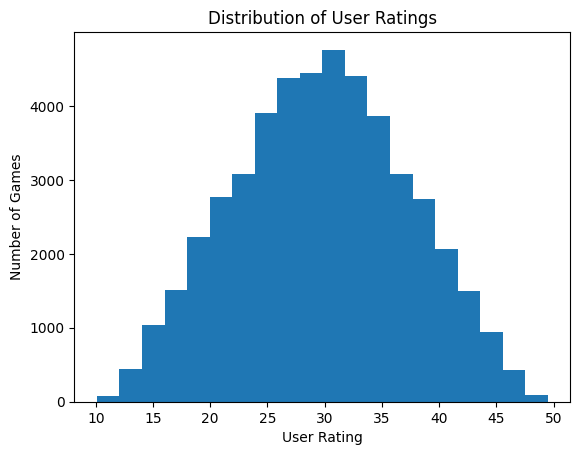

In [214]:
plt.hist(df["User Rating"], bins=20)

plt.xlabel("User Rating")
plt.ylabel("Number of Games")
plt.title("Distribution of User Ratings")
plt.show()

In [215]:
df["User Rating"].value_counts()

,count
User Rating,
30.4,269
31.9,263
31.8,261
28.1,261
29.3,257
...,...
10.1,1
10.8,1
49.5,1


Избор на характеристики:
- Разделяме колоните на категорични и числови
- - За категоричните колони, избираме само тези с по-малко от 50 уникални стойности, за да избегнем "експлозия" при one-hot encoding
- Изключваме целевата променлива от характеристиките
- Извеждаме списъците с избраните характеристики

In [217]:
target_column = "User Rating"
columns_to_drop = ['Developer', 'Publisher', 'Game Title']
df = df.drop(columns=columns_to_drop)
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features = []
for col in categorical_columns:
    if col != target_column and df[col].nunique() < 50:
        categorical_features.append(col)

KeyError: "['Developer', 'Publisher', 'Game Title'] not found in axis"

In [218]:
numeric_features = df.select_dtypes(include=['number']).columns.tolist()
numeric_features = [col for col in numeric_features if col != target_column]

In [219]:
print(f"\nSelected numeric features: {numeric_features}")
print(f"Selected categorical features: {categorical_features}")



Selected numeric features: ['Price', 'Release Year', 'Game Length (Hours)', 'Min Number of Players']
Selected categorical features: ['Age Group Targeted', 'Platform', 'Requires Special Device', 'Genre', 'Multiplayer', 'Graphics Quality', 'Soundtrack Quality', 'Story Quality', 'User Review Text', 'Game Mode']


In [220]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
User Rating,47774.0,29.719329,7.550131,10.10,24.30,29.700,35.1000,49.50
Price,47774.0,39.951371,11.520342,19.99,29.99,39.845,49.9575,59.99
Release Year,47774.0,2016.480952,4.027276,2010.00,2013.00,2016.000,2020.0000,2023.00
Game Length (Hours),47774.0,32.481672,15.872508,5.00,18.80,32.500,46.3000,60.00
Min Number of Players,47774.0,5.116758,2.769521,1.00,3.00,5.000,7.0000,10.00


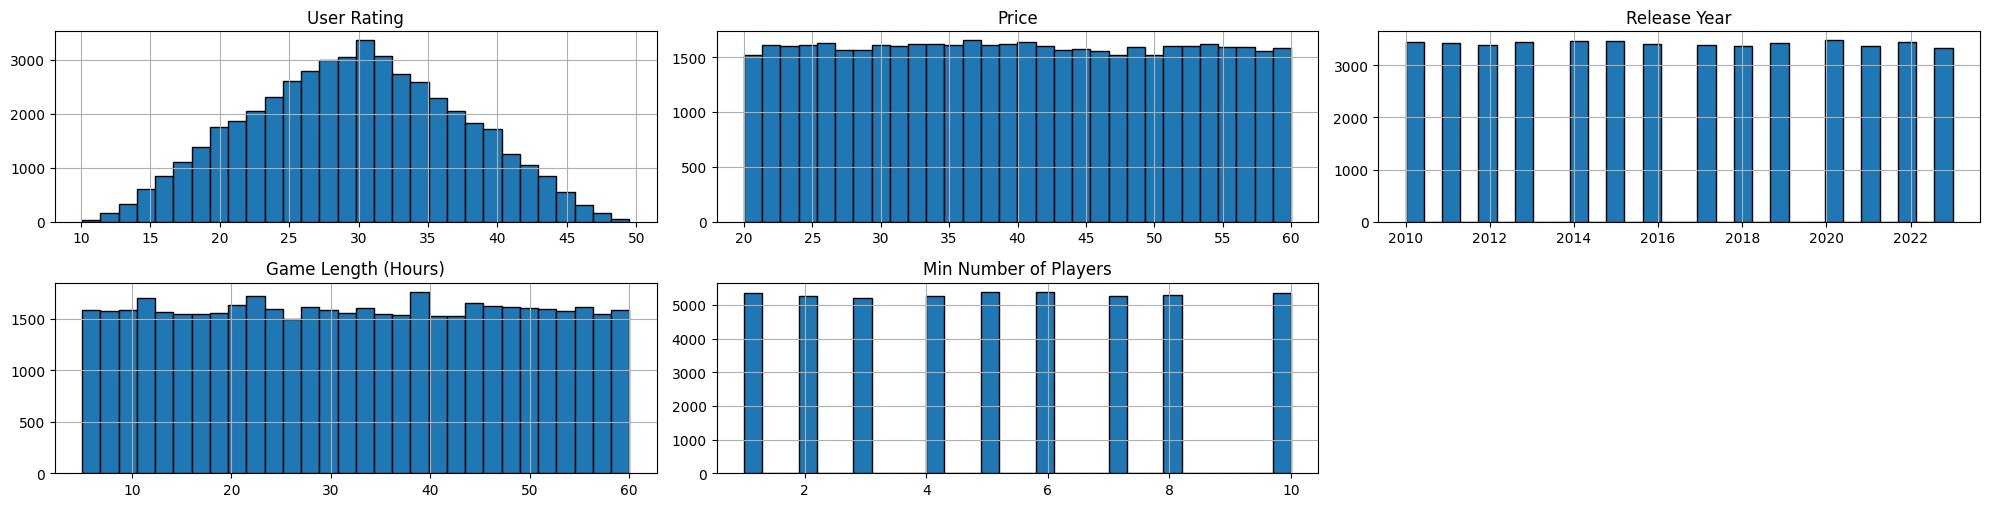

In [221]:
df.hist(figsize=(20, 15), bins=30, edgecolor='black', layout=(len(df.columns) // 3 + 1, 3))
plt.tight_layout()  # Prevent overlapping of subplots
plt.show()

In [222]:
df['User Review Text'].unique()

array(['Solid game, but too many bugs.',
       'Great game, but the graphics could be better.',
       'Solid game, but the graphics could be better.',
       'Great game, but too many bugs.',
       'Solid game, but the gameplay is amazing.',
       'Disappointing game, but the gameplay is amazing.',
       'Great game, but the gameplay is amazing.',
       'Amazing game, but the gameplay is amazing.',
       'Disappointing game, but the graphics could be better.',
       'Amazing game, but too many bugs.',
       'Amazing game, but the graphics could be better.',
       'Disappointing game, but too many bugs.'], dtype=object)

In [223]:
def extract_essential(text):
    text = text.lower()
    if 'bug' in text:
        return 'bugs'
    elif 'graphics could be better' in text:
        return 'bad_graphics'
    elif 'gameplay is amazing' in text:
        return 'amazing_gameplay'
    else:
        return 'other'
df['User Review Text'] = df['User Review Text'].apply(extract_essential)
df['User Review Text'].unique()

array(['bugs', 'bad_graphics', 'amazing_gameplay'], dtype=object)

In [224]:
# ===== КОДИРАНЕ НА КАТЕГОРИЙНИ ДАННИ =====
# One-hot encoding за категорийните признаци
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)
df_encoded.head()
print(f"\nРазмер след кодиране: {df_encoded.shape}")


Размер след кодиране: (47774, 35)


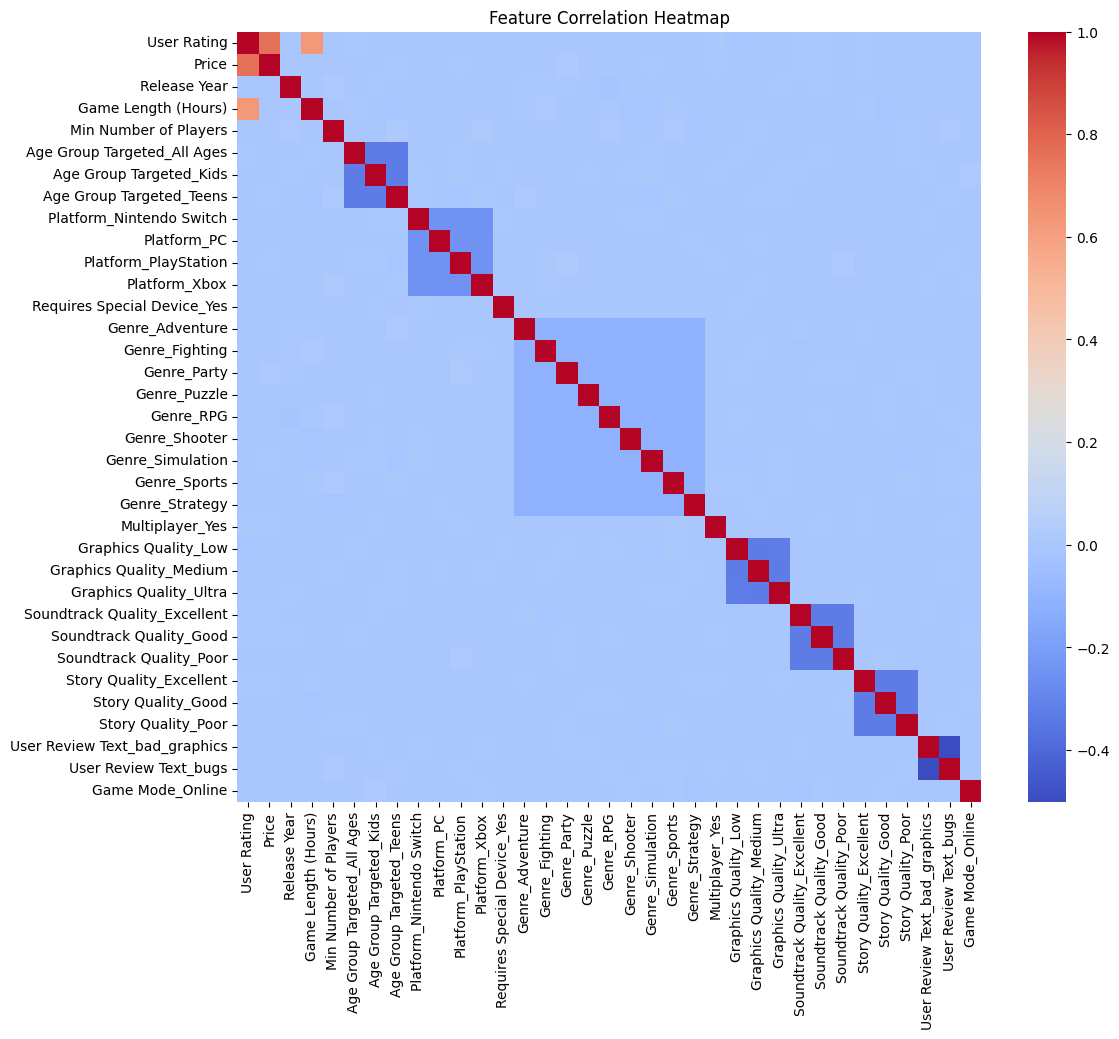

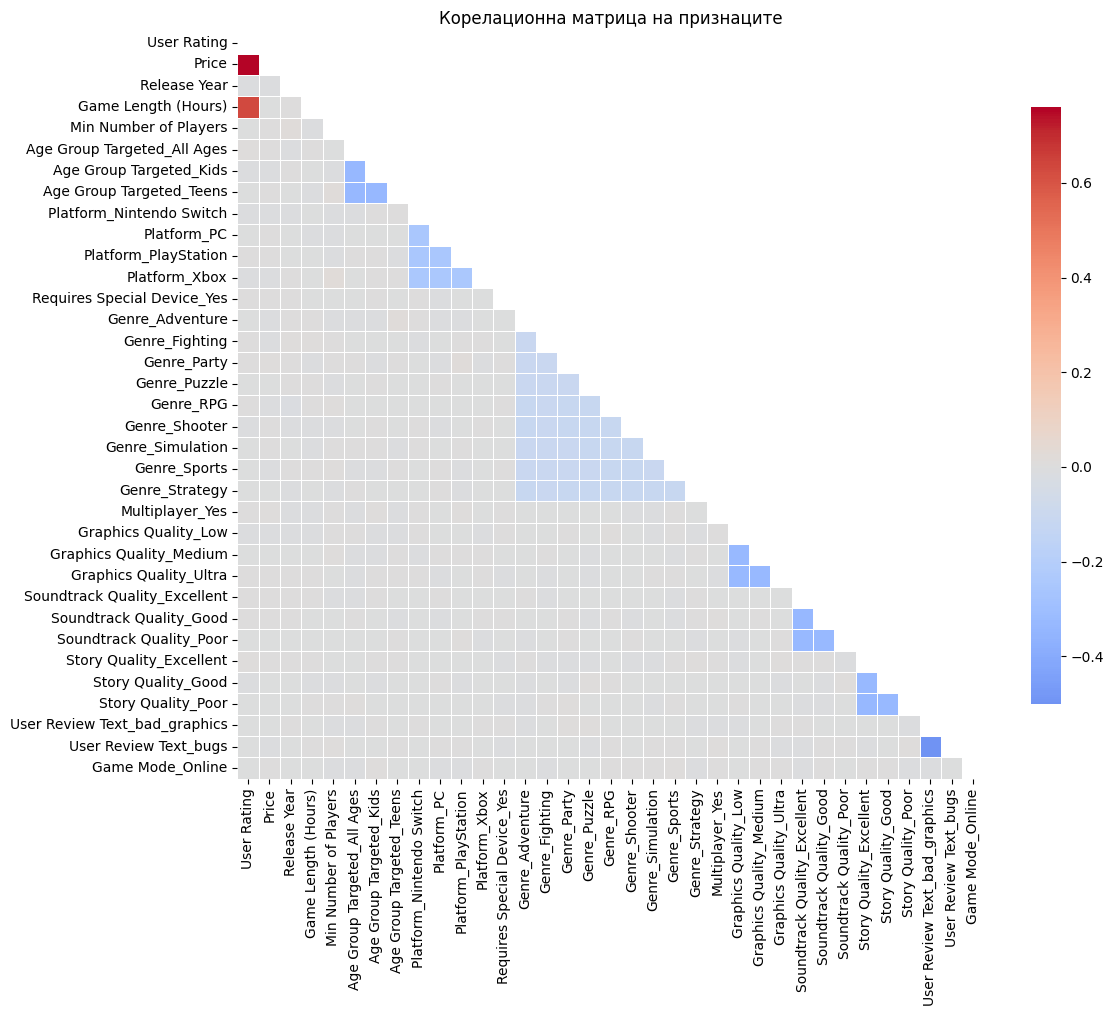

In [225]:
# ===== ВИЗУАЛИЗАЦИЯ НА КОРЕЛАЦИИ =====
# Корелационна матрица
plt.figure(figsize=(12, 10))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

# Корелационна матрица
plt.figure(figsize=(12, 10))
correlation_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корелационна матрица на признаците')
plt.tight_layout()
plt.show()

#===== МОДЕЛ 1: Random Forest =====

Предимства:

- Висока точност - комбинира много модели
- Устойчив на overfitting - не се "запомня" тренировъчните данни
- Работи с липсващи стойности
- Показва важността на всяка характеристика
- Не се нуждае от скалиране на данните
**Подходящ** за:

- Средни до големи dataset-и
- Смесени типове данни (числови + категориални)
- Когато искате добри резултати без много настройване

In [226]:
# ===== ПОДГОТОВКА ЗА МОДЕЛА =====
# Разделяне на данни
y = df_encoded[target_column]
X = df_encoded.drop(columns=[target_column])
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None
)

print(f"\nРазмери на данните:")
print(f"Тренировъчни: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Тестови: X_test {X_test.shape}, y_test {y_test.shape}")



Размери на данните:
Тренировъчни: X_train (38219, 34), y_train (38219,)
Тестови: X_test (9555, 34), y_test (9555,)


In [227]:
# ===== МОДЕЛ 1: RANDOM FOREST С FEATURE SELECTION =====

print(f"\n=== МОДЕЛ 1: RANDOM FOREST ===")

# Създаване и обучение на Random Forest модел
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=10
)

# Обработка на липсващи стойности преди обучението
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

rf_model.fit(X_train_imputed, y_train)



=== МОДЕЛ 1: RANDOM FOREST ===


RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

In [228]:
# Feature selection
selector = SelectFromModel(rf_model, prefit=True)
X_train_selected = selector.transform(X_train_imputed)
X_test_selected = selector.transform(X_test_imputed)

# Получаване на избраните признаци
selected_features = X.columns[selector.get_support()]
feature_importance = rf_model.feature_importances_[selector.get_support()]

print(f"Избрани {len(selected_features)} от {len(X.columns)} признака")


Избрани 2 от 34 признака


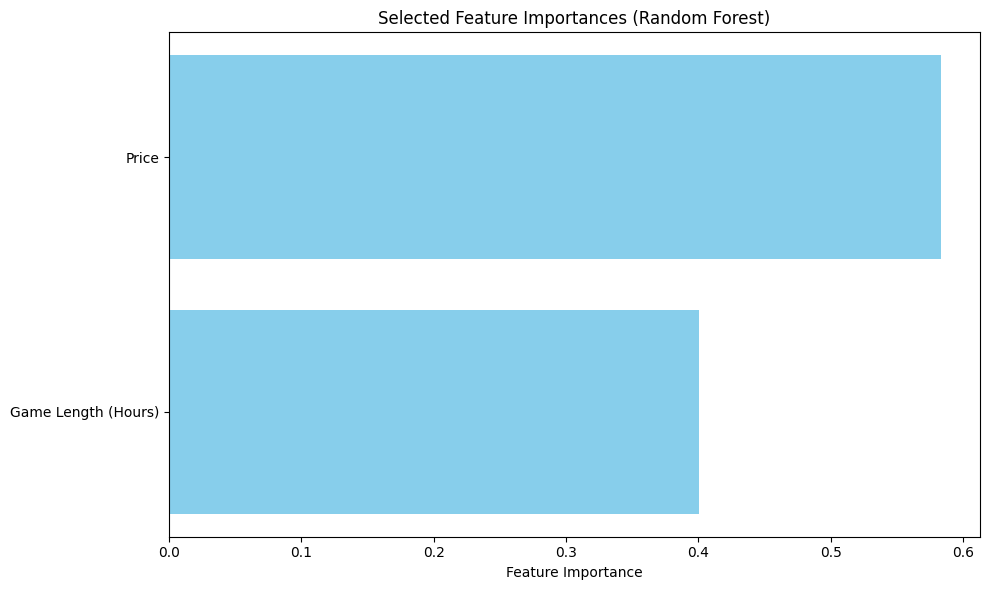

In [229]:
# Create DataFrame with feature names and their importance
feature_importance_df = pd.DataFrame({
    'Feature': selected_columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Selected Feature Importances (Random Forest)")
plt.gca().invert_yaxis()  # Most important at the top
plt.tight_layout()
plt.show()

In [230]:
# Предсказания и оценка
y_pred_rf = rf_model.predict(X_test_imputed)

# Метрики
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\n=== РЕЗУЛТАТИ RANDOM FOREST ===")
print(f"Средна квадратична грешка (MSE): {mse_rf:.4f}")
print(f"Корен от MSE (RMSE): {rmse_rf:.4f}")
print(f"Средна абсолютна грешка (MAE): {mae_rf:.4f}")
print(f"Коефициент на детерминация (R²): {r2_rf:.4f}")



=== РЕЗУЛТАТИ RANDOM FOREST ===
Средна квадратична грешка (MSE): 1.3956
Корен от MSE (RMSE): 1.1814
Средна абсолютна грешка (MAE): 1.0138
Коефициент на детерминация (R²): 0.9759


# ===== МОДЕЛ 2: LINEAR REGRESSION С PIPELINE =====
ъздаване на конвейер за предварителна обработка

Създаваме конвейери за обработка на различните типове данни:
За числовите характеристики: попълваме липсващите стойности със средната стойност и стандартизираме данните
За категоричните характеристики: попълваме липсващите стойности с най-често срещаната стойност и прилагаме one-hot encoding
Обединяваме тези конвейери в един общ преработвач (preprocessor)

In [257]:
# Създаване на preprocessor
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough')




Създаване на модела

Създаваме цялостен конвейер, който включва предварителната обработка и линейния регресионен модел
Това опростява процеса на обучение и предсказване

In [258]:
model2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])



Разделяне на данните

Разделяме данните на характеристики (X) и целева променлива (y)
Използваме функцията train_test_split за разделяне на данните на тренировъчен (80%) и тестов (20%) набор
Задаваме random_state=42 за възпроизводимост на резултатите
Извеждаме размера на получените набори от данни

In [259]:
X = df[numeric_features + categorical_features]
y = df[target_column]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")



Training set size: (38219, 14)
Testing set size: (9555, 14)


Обучение на модела

Обучаваме модела върху тренировъчните данни Функцията fit() изпълнява както предварителната обработка, така и обучението на линейния регресионен модел

In [260]:
print("\nTraining the model...")
model2.fit(X_train, y_train)


Training the model...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Price', 'Release Year',
                                                   'Game Length (Hours)',
                                                   'Min Number of Players']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Age Group Targeted',
                                                   'Platform',
                                                   'Requires Special Device',
                                                   'Genre', 'Multiplayer',
                                                   'Graphics Quality',
                                                   'Soundtrack Quality',
                                                   'Story Quality',
                                                   'User Review Text',
                                                   'Game Mode'])])),
                ('regressor', LinearRegression())])

Оценка на модела

Правим предсказания върху тестовия набор от данни Изчисляваме различни метрики за оценка на точността на модела:
MSE (средно-квадратична грешка) - по-ниски стойности са по-добри
RMSE (корен от средно-квадратичната грешка) - в същите единици като целевата променлива
R² (коефициент на детерминация) - показва каква част от вариацията на данните е обяснена от модела (0-1, по-високи стойности са по-добри)

In [261]:
y_pred = model2.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred)  # Добавено
r2_lr = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")  # Добавено
print(f"R-squared (R²): {r2_lr:.4f}")


Model Evaluation:
Mean Squared Error (MSE): 1.3404
Root Mean Squared Error (RMSE): 1.1578
Mean Absolute Error (MAE): 1.0010
R-squared (R²): 0.9769


Визуализация на предсказанията

Създаваме диаграма, която сравнява действителните рейтинги с предсказаните
Идеалните предсказания биха лежали на червената пунктирана линия
Това ни помага визуално да оценим колко добре работи моделът

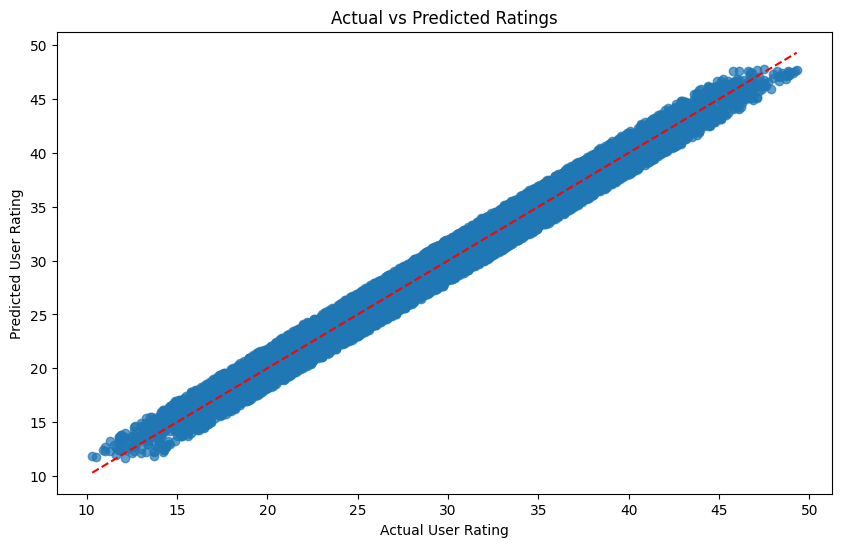

In [236]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel(f'Actual {target_column}')
plt.ylabel(f'Predicted {target_column}')
plt.title('Actual vs Predicted Ratings')
plt.show()  # This will display the plot directly in the Colab output


Анализ на остатъците

Изчисляваме остатъците (разликата между действителните и предсказани стойности)
Визуализираме разпределението на остатъците - в идеалния случай те трябва да имат нормално разпределение около нулата
Създаваме диаграма на остатъците спрямо предсказаните стойности - в идеалния случай не трябва да се наблюдават систематични модели

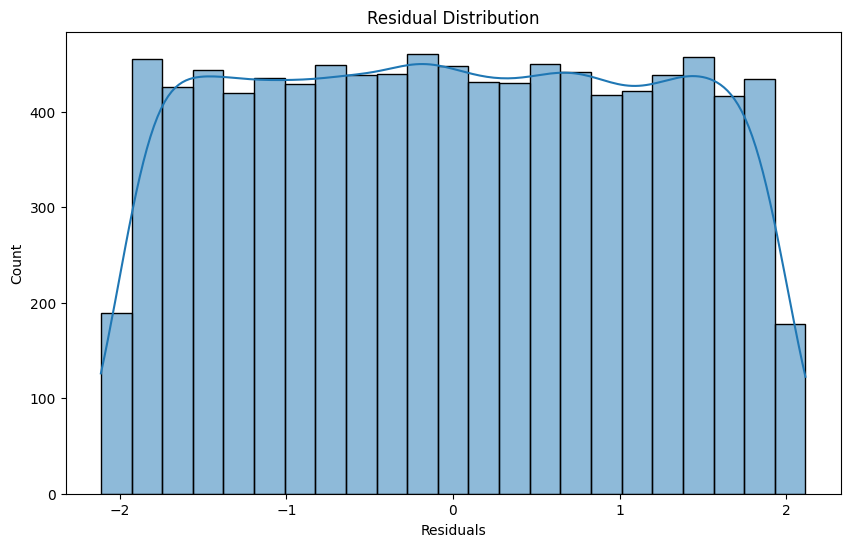

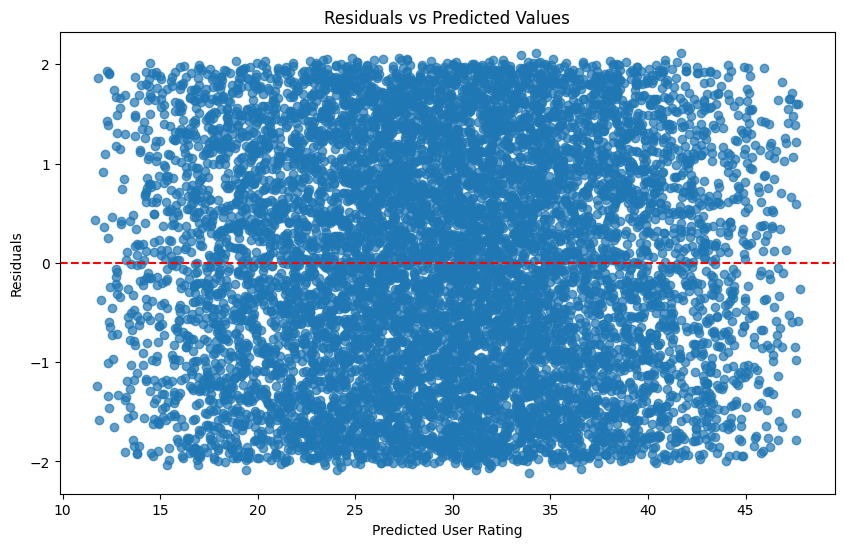

In [237]:
# Residuals
residuals = y_test - y_pred

# Histogram of residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Residual Distribution')
plt.show()  # Show in Colab

# Residuals vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel(f'Predicted {target_column}')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()  # Show in Colab

Анализ на важността на характеристиките Извличаме и анализираме коефициентите на линейния регресионен модел Коефициентите показват относителната важност на всяка характеристика за предсказването на рейтингите Извеждаме топ 10 характеристики с най-голямо абсолютно влияние

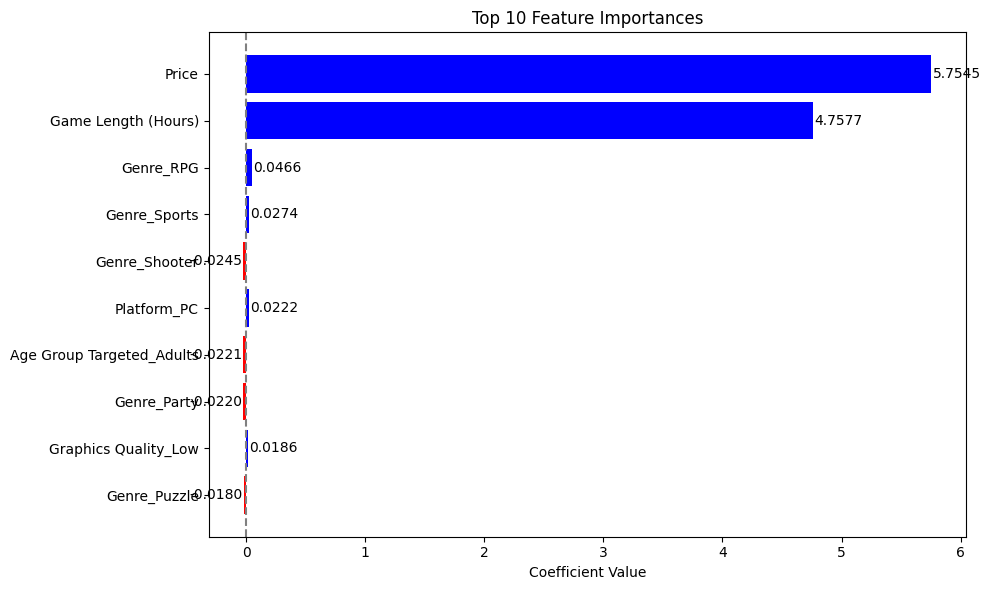

In [238]:
if len(numeric_features) > 0:
    try:
        regressor = model2.named_steps['regressor']
        preprocessor = model2.named_steps['preprocessor']

        # Combine feature names
        feature_names = []
        if len(numeric_features) > 0:
            feature_names.extend(numeric_features)
        if len(categorical_features) > 0:
            cat_features = preprocessor.transformers_[1][1].get_feature_names_out(categorical_features)
            feature_names.extend(cat_features)

        # Get model coefficients
        coef = regressor.coef_

        # Get top 10 absolute coefficients
        sorted_indices = np.argsort(np.abs(coef))[-10:]
        top_features = [feature_names[i] if i < len(feature_names) else f"Index {i}" for i in sorted_indices]
        top_coefficients = coef[sorted_indices]

        # Set colors: red for negative, blue for positive
        colors = ['red' if val < 0 else 'blue' for val in top_coefficients]

        # Plot as bar chart
        plt.figure(figsize=(10, 6))
        bars = plt.barh(top_features, top_coefficients, color=colors)
        plt.xlabel('Coefficient Value')
        plt.title('Top 10 Feature Importances')
        plt.axvline(x=0, color='gray', linestyle='--')

        # Annotate bars with coefficient values
        for bar, value in zip(bars, top_coefficients):
            plt.text(
                x=value + 0.01 if value >= 0 else value - 0.01,
                y=bar.get_y() + bar.get_height() / 2,
                s=f"{value:.4f}",
                va='center',
                ha='left' if value >= 0 else 'right',
                fontsize=10,
                color='black'
            )

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not extract feature importance: {e}")

# ===== МОДЕЛ 3: LinearSVR =====

In [239]:
target3 = df_encoded['User Rating']
attributes3 = df_encoded.drop(columns=['User Rating'])
# 3. Split the data into training and test sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(attributes3, target3, test_size=0.2, random_state=42)

# 4. Train the model
simple_svm = LinearSVR()
simple_svm.fit(X_train, y_train)


LinearSVR()

In [240]:
# 5. (Optional) Evaluate on test data
predictions = simple_svm.predict(X_test)

In [249]:
# 2. Evaluate performance
mse_svm = mean_squared_error(y_test, predictions)
rmse_svm = np.sqrt(mse_svm)
mae_svm = mean_absolute_error(y_test, predictions)
r2_svm = r2_score(y_test, predictions)

In [250]:
# 3. Print the results
print("Mean Absolute Error (MAE):", mae_svm)
print("Mean Squared Error (MSE):", mse_svm)
print("Root Mean Squared Error (RMSE):", rmse_svm)
print("R² Score:", r2_svm)

Mean Absolute Error (MAE): 1.5091535260939044
Mean Squared Error (MSE): 3.3713539818961893
Root Mean Squared Error (RMSE): 1.8361247185025829
R² Score: 0.9417777052095879


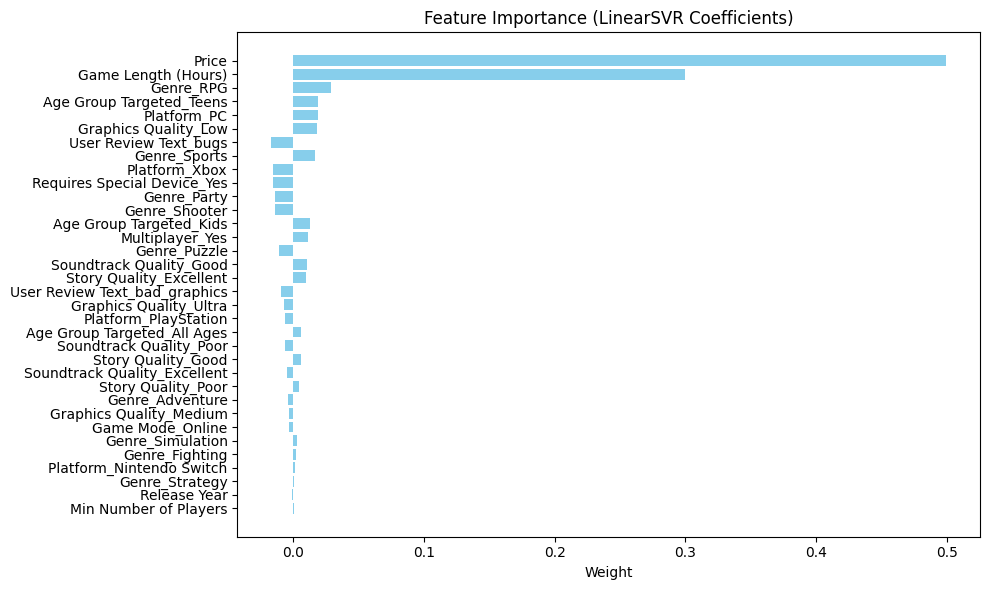

In [251]:
# Get the coefficients (weights) from the trained LinearSVR model
weights = simple_svm.coef_

# Get the names of the features
feature_names = X_train.columns

# Create a DataFrame for easy plotting
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': weights
})

# Sort by absolute weight (importance)
coef_df['AbsWeight'] = np.abs(coef_df['Weight'])
coef_df = coef_df.sort_values(by='AbsWeight', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Weight'], color='skyblue')
plt.xlabel('Weight')
plt.title('Feature Importance (LinearSVR Coefficients)')
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()




=== СРАВНЕНИЕ НА МОДЕЛИТЕ ===
               Модел    RMSE     MSE     MAE      R²
0      Random Forest  1.1814  1.3956  1.0138  0.9759
1  Linear Regression  1.1578  1.3404  1.0010  0.9769
2          LinearSVM  1.8361  3.3714  1.5092  0.9418


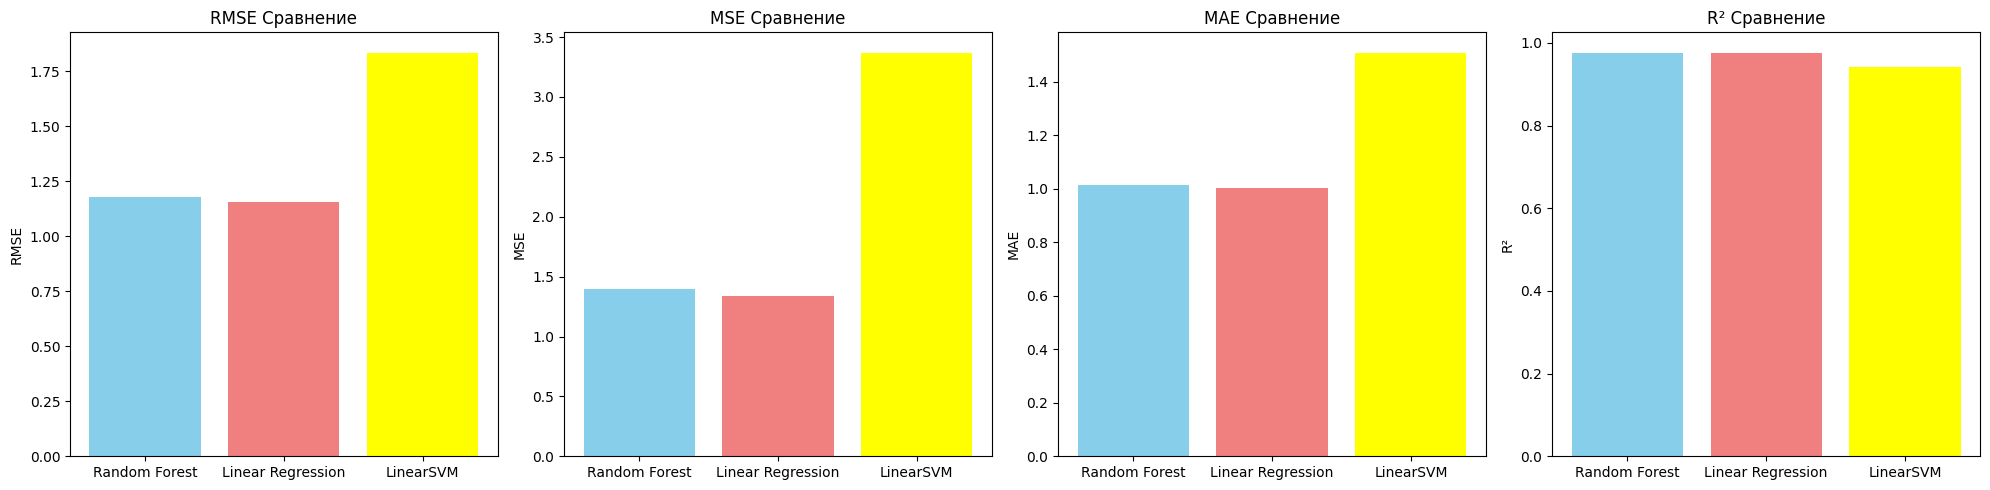

In [262]:
# ===== СРАВНЕНИЕ НА МОДЕЛИТЕ =====
print(f"\n=== СРАВНЕНИЕ НА МОДЕЛИТЕ ===")
comparison_df = pd.DataFrame({
    'Модел': ['Random Forest', 'Linear Regression', 'LinearSVM'],
    'RMSE': [rmse_rf, rmse_lr, rmse_svm],
    'MSE': [mse_rf, mse_lr, mse_svm],
    'MAE': [mae_rf, mae_lr, mae_svm],
    'R²': [r2_rf, r2_lr, r2_svm]
})

print(comparison_df.round(4))

# Визуализация на сравнението
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  # 4 графики

# RMSE
axes[0].bar(comparison_df['Модел'], comparison_df['RMSE'], color=['skyblue', 'lightcoral', 'yellow'])
axes[0].set_title('RMSE Сравнение')
axes[0].set_ylabel('RMSE')

# MSE
axes[1].bar(comparison_df['Модел'], comparison_df['MSE'], color=['skyblue', 'lightcoral', 'yellow'])
axes[1].set_title('MSE Сравнение')
axes[1].set_ylabel('MSE')

# MAE
axes[2].bar(comparison_df['Модел'], comparison_df['MAE'], color=['skyblue', 'lightcoral', 'yellow'])
axes[2].set_title('MAE Сравнение')
axes[2].set_ylabel('MAE')

# R²
axes[3].bar(comparison_df['Модел'], comparison_df['R²'], color=['skyblue', 'lightcoral', 'yellow'])
axes[3].set_title('R² Сравнение')
axes[3].set_ylabel('R²')

plt.tight_layout()
plt.show()

- RMSE (Средна квадратична грешка) – показва средната големина на грешките; по-ниска стойност = по-добро представяне.

- MSE (Квадратична грешка) – също измерва грешката, но наказва големите отклонения по-силно.

- MAE (Средна абсолютна грешка) – средно отклонение без да се наказват силно големите грешки.

- R² (коефициент на детерминация) – измерва каква част от вариацията в данните се обяснява от модела; колкото по-близо до 1 – толкова по-добре.

##Linear Regression има най-ниски стойности на RMSE, MSE и MAE, както и най-висока стойност на R². Това означава, че се представя най-добре сред трите модела – прави най-точни прогнози и обяснява най-много от вариацията в данните.

Random Forest също има много добро представяне – почти толкова добро, колкото линейната регресия.

LinearSVM има най-слаби резултати по всички метрики – най-големи грешки и най-ниско R²